In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

data= pd.read_csv("anti_total.csv".strip('\u202a'), index_col=False)

In [3]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [4]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 400].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [8]:
len(data_filter), len(data_filter['ACCOUNTNO'])

(27968, 27968)

In [9]:
data_filter['Clindamycin'].sum(), data_filter['Gentamicin'].sum()

(624.0, 623.0)

In [10]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9'
]

temp_site = data_filter[all_site_cols].copy()

# robust cleaning（避免奇怪值）
temp_site = (
    temp_site.astype(str)
    .apply(lambda x: x.str.strip())
    .replace(['', 'nan', 'None', 'nan.0'], '0')
    .astype(float)
)

# 建 flag
data_filter = data_filter.copy()
data_filter['Miss_INFECTSITE_flag'] = (temp_site == 0).all(axis=1).astype(int)

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
data_filter = data_filter.copy()
data_filter['ROOMNO'] = data_filter['ROOMNO'].map(roomno_mapping)          

data_filter['SEX'] = data_filter['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    data_filter[col] = data_filter[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols]
y = data_filter[final_cols]

In [13]:
X.shape, y.shape

((27968, 70), (27968, 20))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir', 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
# 找出至少有一種藥物的樣本 (Row sum > 0)
has_label_mask = (y.sum(axis=1) > 0)

# 同步過濾 X 和 y
X = X[has_label_mask]
y = y[has_label_mask]

print(f"原本樣本數: {len(has_label_mask)}")
print(f"過濾後樣本數: {len(y)}")
print(f"已刪除 {len(has_label_mask) - len(y)} 筆因刪除藥物欄位而變成『無給藥』的樣本")

原本樣本數: 27968
過濾後樣本數: 22509
已刪除 5459 筆因刪除藥物欄位而變成『無給藥』的樣本


In [16]:
X.columns

Index(['OTHERINFECTIONSITE_flag', 'AGE', 'CRP', 'StayTime_hours',
       'VITALSIGNSDBP', 'DM', 'Ht', 'HST', 'MAP', 'VITALSIGNSBT',
       'CHECKITEM28SCORE', 'CHECKITEM27', 'CANCER', 'LIVER', 'VITALSIGNSRR',
       'CHECKITEM31SCORE', 'AUTOIMMUNE', 'PCO2', 'INFECTIONSITE5', 'KIDNEY',
       'Absolute Neutrophil count', 'Microscopic RBC level', 'INFECTIONSITE4',
       'FEVER', 'Microscopic WBC level', 'PH', 'RBC', 'WBC', 'GPT',
       'CHECKITEM32SCORE', 'K', 'CHECKITEM30SCORE', 'SEX', 'Neutrophil Seg.',
       'Na', 'VITALSIGNSSPO2', 'Hb', 'Leukocyte level', 'T.Bilirubin',
       'Miss_INFECTSITE_flag', 'INFECTIONSITE2', 'PT', 'INJURELEVEL',
       'INFECTIONSITE9', 'CHECKITEM28A', 'Creatinine', 'INR', 'APTT',
       'INFECTIONSITE3', 'Nitrite level', 'O2 SAT', 'RESPIRATORY', 'PLT',
       'CARDIOVASCULAR', 'BE(ecf)', 'CHECKITEM27SCORE', 'VITALSIGNSGCS', 'CNS',
       'INFECTIONSITE1', 'HCO3', 'Bacteria level', 'Lymphocyte',
       'CHECKITEM29SCORE', 'VITALSIGNSPR'],
      dtype='ob

In [17]:
y[y.columns].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Metronidazole                  1020.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Ampicillin                      423.0
dtype: float64

In [18]:
# ####################### Missing 70~80% #######################

# # 檢驗

# X['Leukocyte level_flag'] = (
#      X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

# X['Nitrite level_flag'] = (
#      X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

# X['Bacteria level_flag'] = (
#      X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

# X['Microscopic RBC level_flag'] = (
#      X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

# X['Microscopic WBC level_flag'] = (
#      X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

# X['PH_flag'] = (
#      X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# # 計分

# X['CHECKITEM29SCORE_flag'] = (
#      X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM30SCORE_flag'] = (
#      X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


# ####################### Missing > 80% #######################

# # 檢驗

# X['HST_flag'] = (
#      X['HST'].fillna('').str.strip().ne('').astype(int))

# X['T.Bilirubin_flag'] = (
#      X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

# X['PT_flag'] = (
#      X['PT'].fillna('').str.strip().ne('').astype(int))

# X['HST_flag'] = (
#      X['HST'].fillna('').str.strip().ne('').astype(int))

# X['INR_flag'] = (
#      X['INR'].fillna('').str.strip().ne('').astype(int))

# X['APTT_flag'] = (
#      X['APTT'].fillna('').str.strip().ne('').astype(int))

# X['PCO2_flag'] = (
#      X['PCO2'].fillna('').str.strip().ne('').astype(int))

# X['HCO3_flag'] = (
#      X['HCO3'].fillna('').str.strip().ne('').astype(int))


# X['BE(ecf)_flag'] = (
#      X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

# X['O2 SAT_flag'] = (
#      X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# # 計分

# X['CHECKITEM28A_flag'] = (
#      X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM27_flag'] = (
#      X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM27SCORE_flag'] = (
#      X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM28SCORE_flag'] = (
#      X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM31SCORE_flag'] = (
#      X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM32SCORE_flag'] = (
#      X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


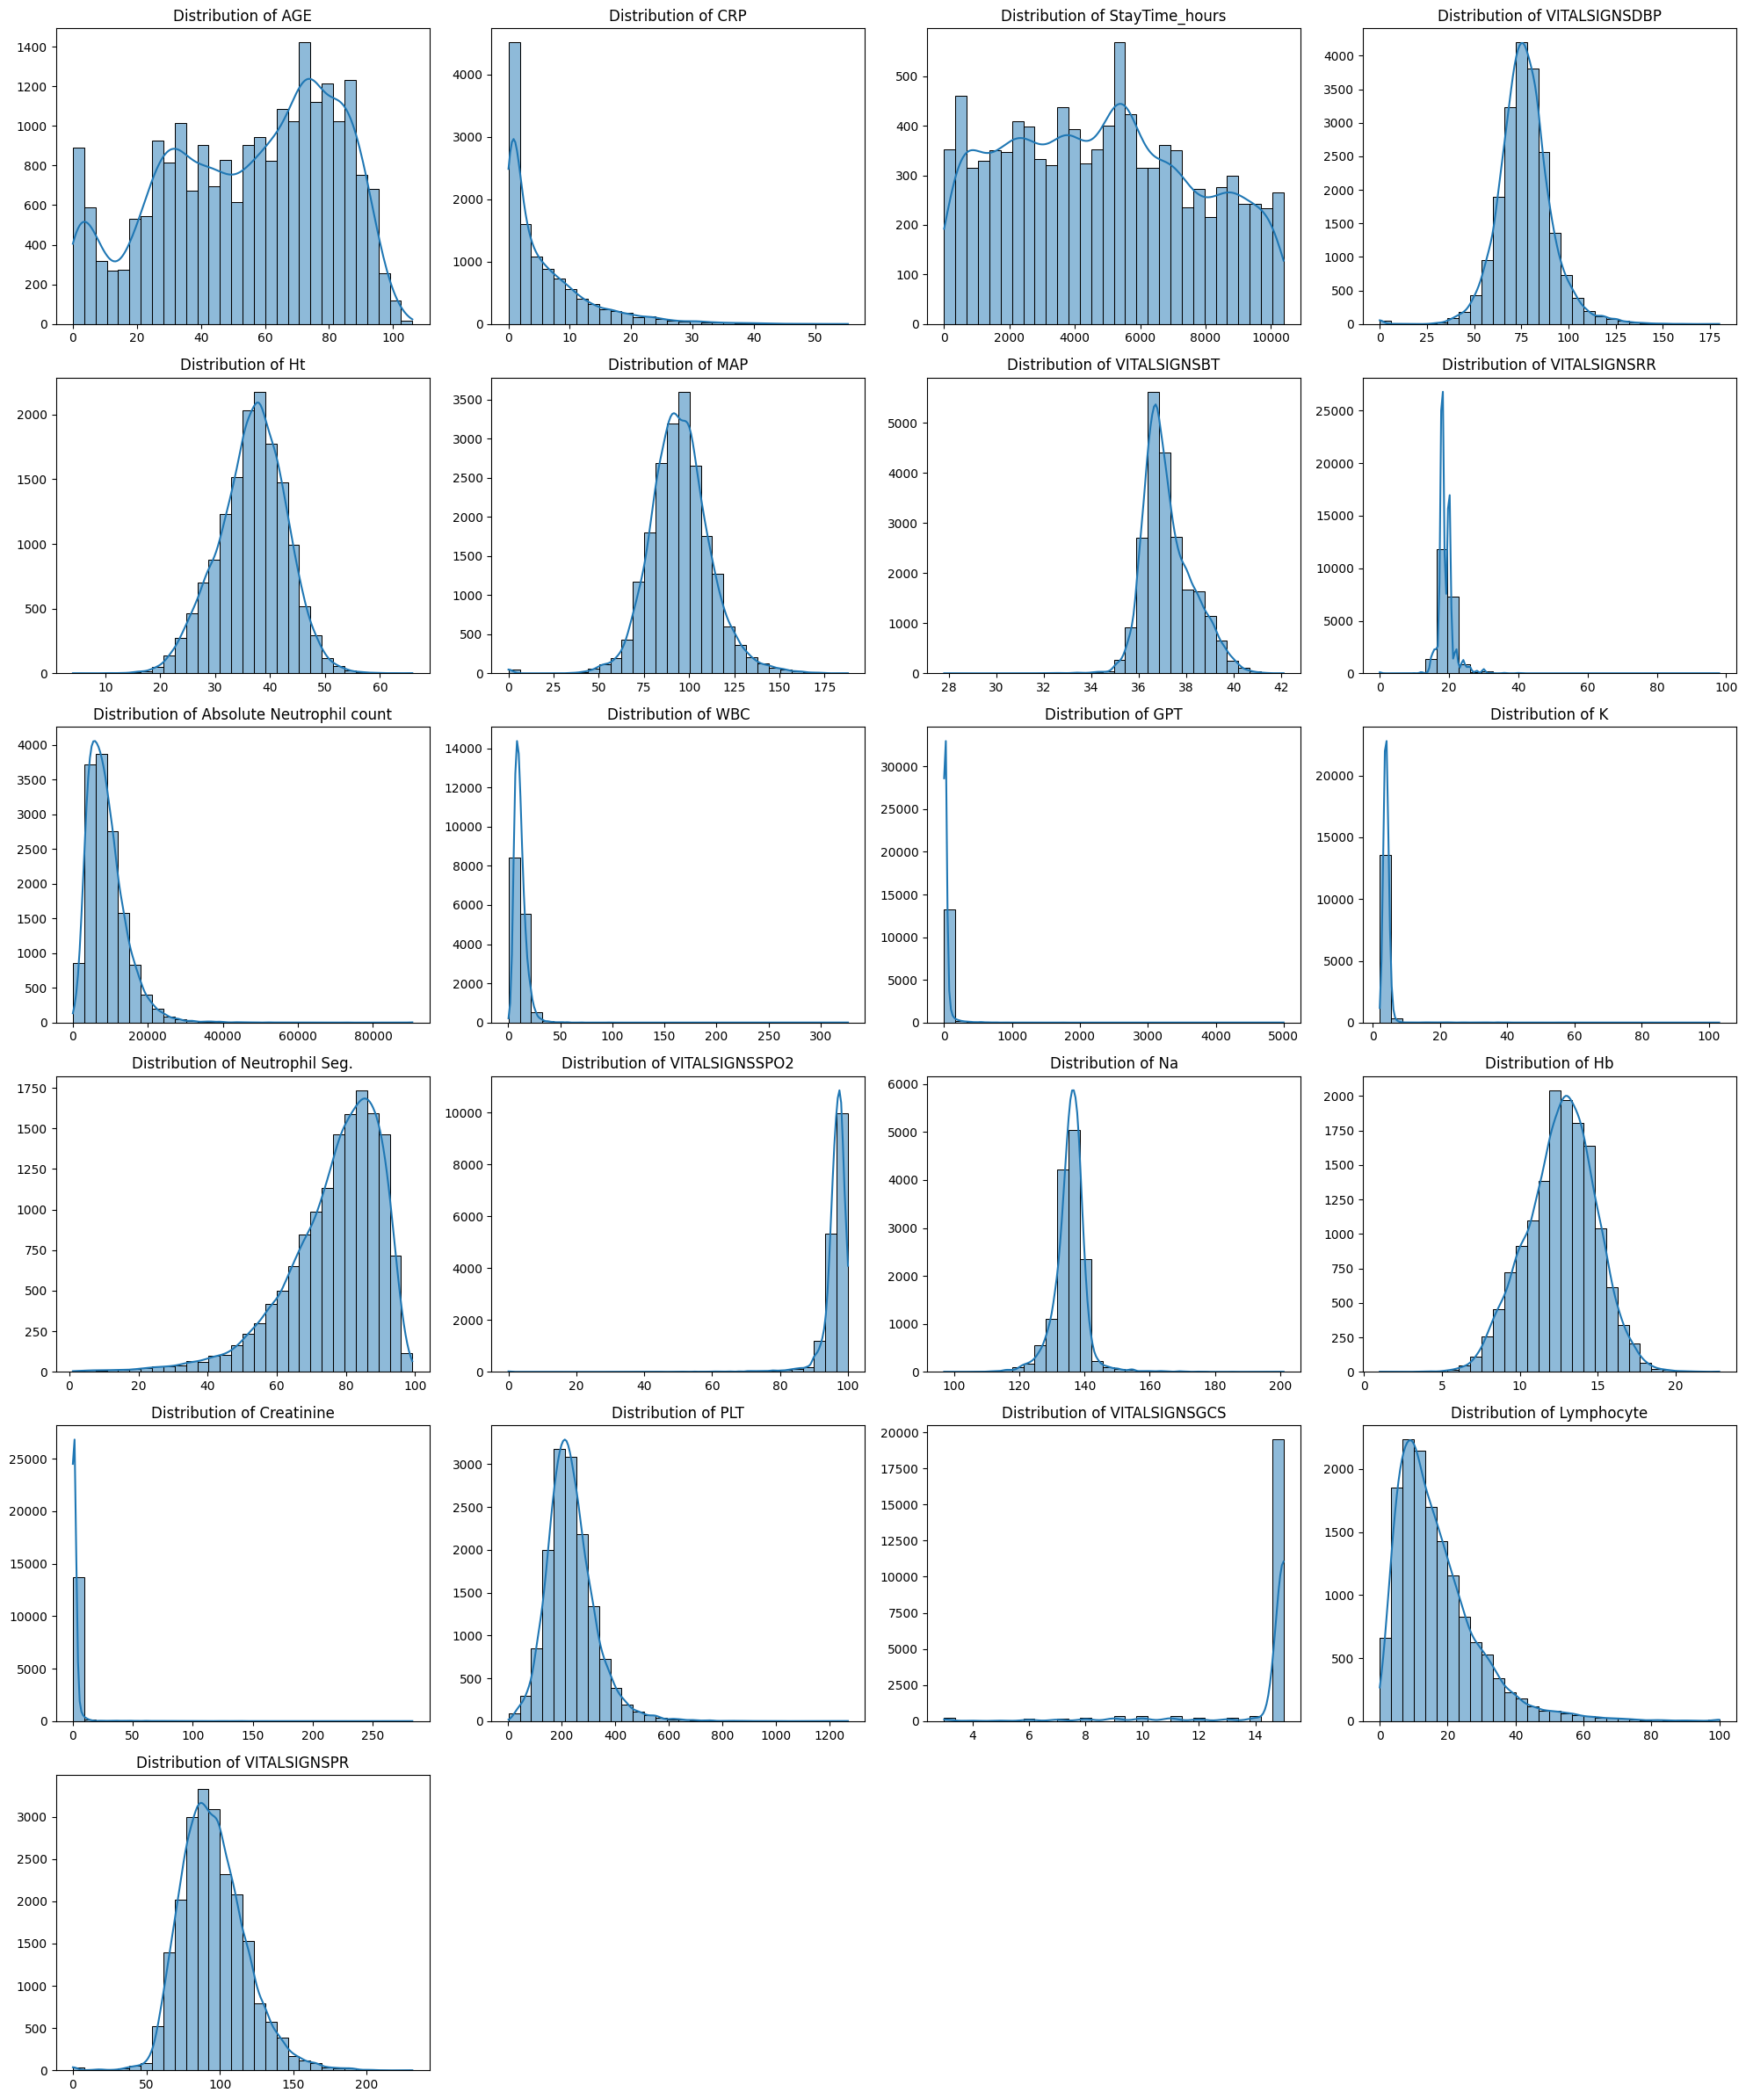

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [20]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 7229

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              201                   202   
VITALSIGNSBT                              190                   196   
MAP                                       200                   185   
VITALSIGNSDBP                             188                   190   
VITALSIGNSRR                              109                   216   
WBC                                       147                   147   
PLT                                       144                   147   
Absolute Neutrophil count                 145                   145   
Neutrophil Seg.                           144                   144   
RBC                                       145                   143   

                           Total_Outliers  
VITALSIGNSPR                          403  
VITALSIGNSBT                          386  
MAP                                   385  
VITAL

In [21]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((18007, 64), (18007, 15), (4502, 64), (4502, 15))

In [23]:
X_train.isnull().sum(), X_test.isnull().sum()

(OTHERINFECTIONSITE_flag        0
 AGE                            0
 CRP                         8899
 StayTime_hours              9839
 VITALSIGNSDBP               1661
                            ...  
 HCO3                       15448
 Bacteria level             12381
 Lymphocyte                  6437
 CHECKITEM29SCORE           13840
 VITALSIGNSPR                 619
 Length: 64, dtype: int64,
 OTHERINFECTIONSITE_flag       0
 AGE                           0
 CRP                        2249
 StayTime_hours             2527
 VITALSIGNSDBP               421
                            ... 
 HCO3                       3902
 Bacteria level             3110
 Lymphocyte                 1627
 CHECKITEM29SCORE           3459
 VITALSIGNSPR                144
 Length: 64, dtype: int64)

In [24]:
X_train.dtypes, X_test.dtypes

(OTHERINFECTIONSITE_flag      int64
 AGE                        float64
 CRP                        float64
 StayTime_hours             float64
 VITALSIGNSDBP              float64
                             ...   
 HCO3                       float64
 Bacteria level             float64
 Lymphocyte                 float64
 CHECKITEM29SCORE           float64
 VITALSIGNSPR               float64
 Length: 64, dtype: object,
 OTHERINFECTIONSITE_flag      int64
 AGE                        float64
 CRP                        float64
 StayTime_hours             float64
 VITALSIGNSDBP              float64
                             ...   
 HCO3                       float64
 Bacteria level             float64
 Lymphocyte                 float64
 CHECKITEM29SCORE           float64
 VITALSIGNSPR               float64
 Length: 64, dtype: object)

In [25]:
y_train.sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    4375.0
Flomoxef                       4171.0
Cefazolin                      1912.0
Cefixime                       1737.0
Ciprofloxacin                  1685.0
Azithromycin                   1650.0
Cefuroxime                     1348.0
Piperacillin/Tazobactam        1195.0
Cefoperazone/sulbactam         1129.0
Metronidazole                   801.0
Levofloxacin                    565.0
Gentamicin                      509.0
Clindamycin                     503.0
Ceftriaxone                     468.0
Ampicillin                      350.0
dtype: float64

In [26]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
            'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [27]:
# vital sign impute

vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
            'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [28]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['RBC'] = np.log1p(X_train['RBC'])
X_test['RBC'] = np.log1p(X_test['RBC'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

X_train['HST'] = np.log1p(X_train['HST'])
X_test['HST'] = np.log1p(X_test['HST'])

X_train['CHECKITEM27'] = np.log1p(X_train['CHECKITEM27'])
X_test['CHECKITEM27'] = np.log1p(X_test['CHECKITEM27'])

X_train['O2 SAT'] = np.log1p(X_train['O2 SAT'])
X_test['O2 SAT'] = np.log1p(X_test['O2 SAT'])

X_train['APTT'] = np.log1p(X_train['APTT'])
X_test['APTT'] = np.log1p(X_test['APTT'])

X_train['PH'] = np.log1p(X_train['PH'])
X_test['PH'] = np.log1p(X_test['PH'])

X_train['CHECKITEM28A'] = np.log1p(X_train['CHECKITEM28A'])
X_test['CHECKITEM28A'] = np.log1p(X_test['CHECKITEM28A'])

In [29]:
# fill score
# score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
#               'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
#               'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
#               'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
#               'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

score_cols = ['Leukocyte level', 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level', 'PH',
              'CHECKITEM29SCORE', 'CHECKITEM30SCORE', # 70~80% missing
              'HST','T.Bilirubin', 'PT', 'HST', 'INR', 'APTT', 'PCO2', 'HCO3', 'BE(ecf)',
              'O2 SAT', 'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 
              'CHECKITEM31SCORE', 'CHECKITEM32SCORE'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [30]:
y_train.sum(axis=1).mean() # 每人平均用1.4個抗生素

1.2438496140389848

In [31]:
# drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
#              'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
#              'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
#              'CHECKITEM31SCORE', 'CHECKITEM32SCORE', 'OTHERINFECTIONSITE_flag']

drop_cols = ['OTHERINFECTIONSITE_flag']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [32]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
               'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [33]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(18007, 63)

In [34]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone',
       'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin',
       'Levofloxacin', 'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [35]:
X_train.columns

Index(['AGE', 'CRP', 'StayTime_hours', 'VITALSIGNSDBP', 'DM', 'Ht', 'HST',
       'MAP', 'VITALSIGNSBT', 'CHECKITEM28SCORE', 'CHECKITEM27', 'CANCER',
       'LIVER', 'VITALSIGNSRR', 'CHECKITEM31SCORE', 'AUTOIMMUNE', 'PCO2',
       'INFECTIONSITE5', 'KIDNEY', 'Absolute Neutrophil count',
       'Microscopic RBC level', 'INFECTIONSITE4', 'FEVER',
       'Microscopic WBC level', 'PH', 'RBC', 'WBC', 'GPT', 'CHECKITEM32SCORE',
       'K', 'CHECKITEM30SCORE', 'SEX', 'Neutrophil Seg.', 'Na',
       'VITALSIGNSSPO2', 'Hb', 'Leukocyte level', 'T.Bilirubin',
       'Miss_INFECTSITE_flag', 'INFECTIONSITE2', 'PT', 'INJURELEVEL',
       'INFECTIONSITE9', 'CHECKITEM28A', 'Creatinine', 'INR', 'APTT',
       'INFECTIONSITE3', 'Nitrite level', 'O2 SAT', 'RESPIRATORY', 'PLT',
       'CARDIOVASCULAR', 'BE(ecf)', 'CHECKITEM27SCORE', 'VITALSIGNSGCS', 'CNS',
       'INFECTIONSITE1', 'HCO3', 'Bacteria level', 'Lymphocyte',
       'CHECKITEM29SCORE', 'VITALSIGNSPR'],
      dtype='object')

In [36]:
# GaussianMixture?

In [37]:
cluster_features = ['WBC', 'CRP', 'Lymphocyte', 'Neutrophil Seg.',  'Absolute Neutrophil count',  'Hb', 'Lymphocyte', 'MAP', 
                    'VITALSIGNSBT', 'VITALSIGNSDBP', 'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSGCS', 'VITALSIGNSSPO2']

gmm = GaussianMixture(n_components=3, covariance_type='diag', random_state=123)

In [38]:
X_train['cluster'] = gmm.fit_predict(X_train[cluster_features])
X_test['cluster'] = gmm.predict(X_test[cluster_features])

In [39]:
gmm.aic(X_train[cluster_features]), gmm.bic(X_train[cluster_features]), gmm.score(X_train[cluster_features])

(46961.03953477469, 47631.71189788927, -1.299190301959646)

In [40]:
X_train['cluster'].unique()

array([2, 1, 0], dtype=int64)

In [41]:
len(X_train[X_train['cluster'] == 0]), len(X_train[X_train['cluster'] == 1]), len(X_train[X_train['cluster'] == 2])

(5792, 4711, 7504)

In [42]:
#看看每個cluster的抗生素種類和分配
X_train_cluster = X_train.copy()
df_analysis = pd.concat([X_train_cluster, y_train], axis=1)

In [43]:
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_rate = subset[y_train.columns].mean().sort_values(ascending=False)
    print(drug_rate.head(15))

cluster 0
Amoxicillin/Clavulanic acid    0.424896
Azithromycin                   0.121720
Flomoxef                       0.118612
Cefuroxime                     0.106181
Cefixime                       0.104454
Ciprofloxacin                  0.091333
Cefazolin                      0.039019
Clindamycin                    0.031423
Metronidazole                  0.027797
Levofloxacin                   0.025725
Cefoperazone/sulbactam         0.024344
Piperacillin/Tazobactam        0.020028
Ceftriaxone                    0.013122
Gentamicin                     0.008115
Ampicillin                     0.003626
dtype: float64
cluster 1
Flomoxef                       0.234770
Amoxicillin/Clavulanic acid    0.199745
Cefazolin                      0.181702
Cefixime                       0.093823
Azithromycin                   0.090214
Ciprofloxacin                  0.073445
Cefuroxime                     0.073233
Gentamicin                     0.056676
Piperacillin/Tazobactam        0.045001
Cefop

In [44]:
# 相對提升
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate).sort_values(ascending=False) # 明顯偏?
    print(lift.head(15))

cluster 0
Amoxicillin/Clavulanic acid    1.748825
Cefuroxime                     1.418398
Azithromycin                   1.328367
Clindamycin                    1.124906
Cefixime                       1.082850
Ciprofloxacin                  0.976042
Levofloxacin                   0.819881
Metronidazole                  0.624894
Flomoxef                       0.512070
Ceftriaxone                    0.504871
Cefoperazone/sulbactam         0.388274
Cefazolin                      0.367480
Piperacillin/Tazobactam        0.301789
Gentamicin                     0.287073
Ampicillin                     0.186537
dtype: float64
cluster 1
Gentamicin                     2.005034
Ampicillin                     1.823798
Cefazolin                      1.711253
Ceftriaxone                    1.086261
Flomoxef                       1.013545
Azithromycin                   0.984540
Cefuroxime                     0.978267
Cefixime                       0.972637
Clindamycin                    0.866294
Levof

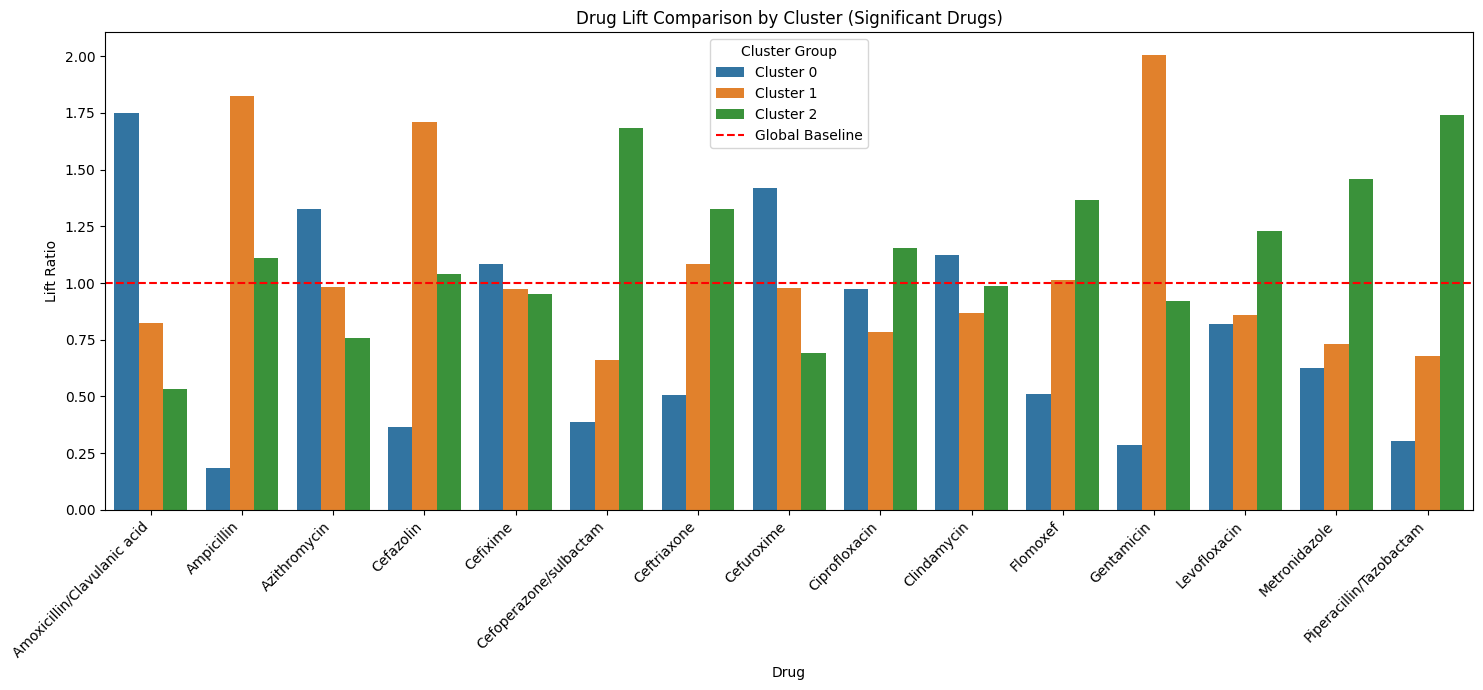

In [45]:
# 1. 整理資料存入 list
lift_records = []
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate)
    
    for drug, val in lift.items():
        lift_records.append({
            'Cluster': f'Cluster {c}',
            'Drug': drug,
            'Lift': val
        })

df_lift_plot = pd.DataFrame(lift_records)

# 2. 繪圖：只挑出 Lift 較顯著的藥物（例如 Lift > 1.5 的藥物）
# 否則藥物太多圖會擠在一起
significant_drugs = df_lift_plot[df_lift_plot['Lift'] > 1.0]['Drug'].unique()
df_filtered = df_lift_plot[df_lift_plot['Drug'].isin(significant_drugs)]

plt.figure(figsize=(15, 7))
sns.barplot(data=df_filtered, x='Drug', y='Lift', hue='Cluster')

# 畫一條紅線代表基準線 (Lift=1)
plt.axhline(1, ls='--', color='red', label='Global Baseline')

plt.title('Drug Lift Comparison by Cluster (Significant Drugs)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Lift Ratio')
plt.legend(title='Cluster Group')
plt.tight_layout()
plt.show()


In [46]:
# 每群抗生素數量
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_num = subset[y_train.columns].sum(axis=1).mean()
    print(drug_num)

cluster 0
1.1603936464088398
cluster 1
1.2373169178518362
cluster 2
1.312366737739872


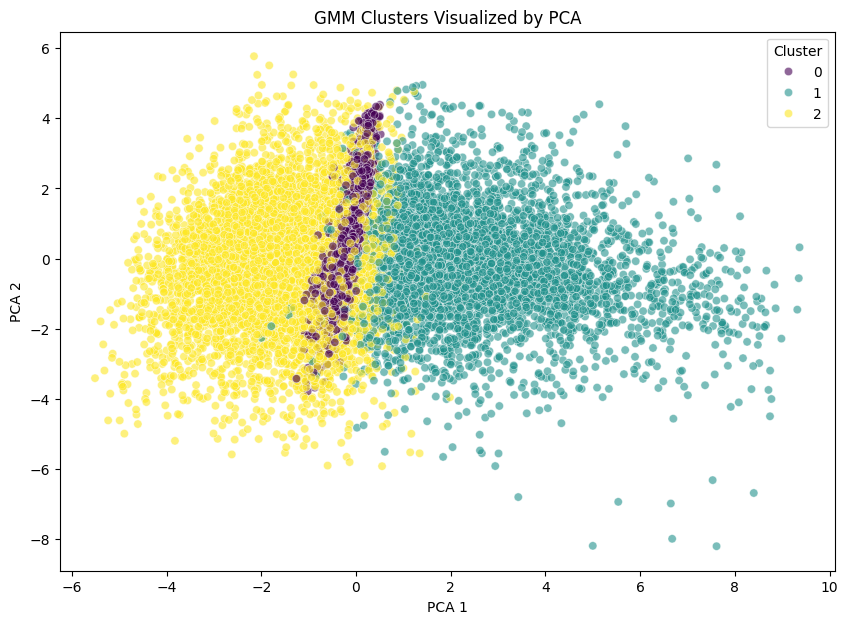

In [47]:
# PCA 降到 2 維
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train[cluster_features])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_train_pca[:, 0], 
    y=X_train_pca[:, 1], 
    hue=X_train['cluster'], # 根據 GMM 分群上色
    palette='viridis', 
    alpha=0.6
)

plt.title('GMM Clusters Visualized by PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()


In [48]:
# 挑選關鍵重症指標
severity_indicators = cluster_features

cols_to_show = [c for c in severity_indicators if c in cluster_features]

cluster_summary = X_train.groupby('cluster')[cols_to_show].mean().T
cluster_summary # 0:、1:、2:

cluster,0,1,2
WBC,-0.002864,-0.712831,0.449725
CRP,-0.024209,-0.359970,0.244674
Lymphocyte,-0.190751,1.202871,-0.607928
Neutrophil Seg.,0.165039,-1.176008,0.610910
Absolute Neutrophil count,0.059589,-0.989382,0.575139
Hb,0.059439,0.034915,-0.067798
Lymphocyte,-0.190751,1.202871,-0.607928
MAP,0.046329,0.106920,-0.102883
VITALSIGNSBT,-0.142631,-0.200313,0.235847
VITALSIGNSDBP,0.109779,0.080175,-0.135067


In [49]:
# cluster prob
cluster_prob_train = gmm.predict_proba(X_train[cluster_features])
cluster_prob_test = gmm.predict_proba(X_test[cluster_features])

In [50]:
def cluster_prob(df, cluster_prob):
    cluster_df = pd.DataFrame(
        cluster_prob,
        columns=[f'cluster_{i}' for i in range(cluster_prob.shape[1])]
    )
    final_df = pd.concat([df.reset_index(drop=True), cluster_df], axis=1)
    return final_df

X_train = cluster_prob(X_train, cluster_prob_train)
X_test = cluster_prob(X_test, cluster_prob_test)

In [51]:
X_train = X_train.drop(columns='cluster')
X_test = X_test.drop(columns='cluster')

In [52]:
X_train

,AGE,CRP,StayTime_hours,VITALSIGNSDBP,DM,Ht,HST,MAP,VITALSIGNSBT,CHECKITEM28SCORE,CHECKITEM27,CANCER,LIVER,VITALSIGNSRR,CHECKITEM31SCORE,AUTOIMMUNE,PCO2,INFECTIONSITE5,KIDNEY,Absolute Neutrophil count,Microscopic RBC level,INFECTIONSITE4,FEVER,Microscopic WBC level,PH,RBC,WBC,GPT,CHECKITEM32SCORE,K,CHECKITEM30SCORE,SEX,Neutrophil Seg.,Na,VITALSIGNSSPO2,Hb,Leukocyte level,T.Bilirubin,Miss_INFECTSITE_flag,INFECTIONSITE2,PT,INJURELEVEL,INFECTIONSITE9,CHECKITEM28A,Creatinine,INR,APTT,INFECTIONSITE3,Nitrite level,O2 SAT,RESPIRATORY,PLT,CARDIOVASCULAR,BE(ecf),CHECKITEM27SCORE,VITALSIGNSGCS,CNS,INFECTIONSITE1,HCO3,Bacteria level,Lymphocyte,CHECKITEM29SCORE,VITALSIGNSPR,cluster_0,cluster_1,cluster_2
0,0.405343,-0.024209,-0.007209,-0.369563,0,0.845960,-0.045268,-0.586344,-1.532864,-1.0,0.027750,0,0,-0.468395,-1.0,0,-1.0,0,0,0.121690,-1.0,0,1,-1.0,0.054845,-0.063051,-0.135863,-0.225232,-1.0,1.084803,-1.0,1,0.611570,0.650249,0.178728,0.790647,-1.0,-1.0,1,0,10.6,2.0,0,0.078313,-0.241951,0.92,-1.082436,0,-1.0,0.138227,0,0.404476,0,-0.013928,-1.0,0.311578,0,0,-1.0,-1.0,-0.708140,-1.0,-1.165510,0.0,5.418370e-03,9.945816e-01
1,0.405343,1.346558,0.681102,0.021142,0,0.194477,-0.045268,0.319431,0.973433,-1.0,0.027750,1,1,-0.468395,-1.0,1,-1.0,0,1,0.464065,2.0,0,1,1.0,1.141017,0.146931,0.392249,-0.046643,-1.0,-0.605760,-1.0,0,0.323185,-1.064288,-0.159114,0.228180,1.0,-1.0,1,0,-1.0,3.0,0,0.078313,-0.253843,-1.00,-0.078220,0,0.0,0.138227,1,-1.293098,0,-0.013928,-1.0,0.311578,1,0,-1.0,2.0,-0.169633,-1.0,-0.928747,0.0,5.150504e-03,9.948495e-01
2,0.740936,1.328551,-0.955854,-1.385397,1,-2.574327,5.089653,-1.362723,-1.845029,0.0,-0.420185,0,1,1.022628,-1.0,1,47.0,1,1,-0.869420,-1.0,0,1,-1.0,0.054845,-2.878686,-0.135863,0.727897,2.0,0.427318,0.0,1,-2.235063,0.650249,-0.159114,-2.640407,-1.0,-1.0,0,1,15.1,3.0,0,0.078313,1.016129,1.36,11.599298,0,-1.0,0.213575,1,-0.445731,1,4.127071,0.0,-3.158482,1,1,31.2,-1.0,-0.106279,3.0,-1.118157,0.0,9.981053e-01,1.894705e-03
3,0.600697,0.148733,-0.007209,0.177424,0,0.560936,-0.045268,-0.262853,1.359547,1.0,3.170313,1,0,0.549499,-1.0,1,-1.0,0,1,1.669638,5.0,0,1,4.0,-0.547964,0.293593,1.600193,0.676494,1.0,-0.605760,0.0,1,1.309274,-3.786870,-1.902340,1.240622,4.0,-1.0,0,0,14.1,2.0,0,-2.173390,0.158265,1.23,0.568497,1,1.0,0.138227,1,1.711981,1,-0.013928,0.0,0.311578,1,0,-1.0,6.0,-1.310001,0.0,0.397126,0.0,4.081259e-06,9.999959e-01
4,0.585657,-0.024209,-1.449773,0.646270,1,0.051965,-0.045268,1.483999,-0.510441,-1.0,0.027750,0,1,-0.468395,-1.0,1,-1.0,0,1,0.059589,-1.0,0,1,-1.0,0.054845,0.102399,-0.002864,-0.133309,-1.0,-0.144987,-1.0,1,0.165039,0.087101,0.513140,0.059439,-1.0,-1.0,1,0,-1.0,4.0,0,0.078313,-0.218358,-1.00,-0.078220,0,-1.0,0.138227,1,0.057509,1,-0.013928,-1.0,0.311578,1,0,-1.0,-1.0,-0.190751,-1.0,-0.976099,1.0,2.678145e-26,2.318942e-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18002,0.190339,-0.024209,-0.007209,0.724411,0,-2.207868,-0.045268,0.642922,-0.208999,-1.0,0.027750,0,1,-0.468395,-1.0,1,-1.0,0,1,0.059589,-1.0,0,1,-1.0,0.054845,0.102399,-0.002864,-1.478684,-1.0,-0.766055,-1.0,0,0.165039,0.650249,0.513140,-2.134186,-1.0,-1.0,0,1,10.2,3.0,0,0.078313,1.731387,0.89,0.728312,0,-1.0,0.138227,1,0.057509,1,-0.013928,-1.0,0.311578,1,0,-1.0,-1.0,-0.190751,-1.0,0.113010,0.0,4.751911e-02,9.524809e-01
18003,0.523394,-0.690899,-0.007209,-0.291422,1,-2.268944,-0.045268,-0.068758,-0.510441,-1.0,0.027750,1,1,0.549499,-1.0,1,-1.0,0,1,-2.111207,-1.0,0,1,-1.0,0.054845,-3.120578,-2.015767,-1.097628,-1.0,-0.448912,-1.0,0,-1.416424,0.087101,0.513140,-2.415420,-1.0,0.5,1,0,-1.0,3.0,0,0.078313,2.038641,-1.00,-0.078220,0,-1.0,0.138227,1,-0.615446,1,-0.013928,-1.0,0.311578,1,0,-1.0,-1.0,0.960176,-1.0,-1.165510,0.0,1.000000e+00,1.790793e-10
18004,-2.683555,0.027788,-0.007209,-0.056999,0,-0.721671,-0.045268,

In [53]:
X_train.columns

Index(['AGE', 'CRP', 'StayTime_hours', 'VITALSIGNSDBP', 'DM', 'Ht', 'HST',
       'MAP', 'VITALSIGNSBT', 'CHECKITEM28SCORE', 'CHECKITEM27', 'CANCER',
       'LIVER', 'VITALSIGNSRR', 'CHECKITEM31SCORE', 'AUTOIMMUNE', 'PCO2',
       'INFECTIONSITE5', 'KIDNEY', 'Absolute Neutrophil count',
       'Microscopic RBC level', 'INFECTIONSITE4', 'FEVER',
       'Microscopic WBC level', 'PH', 'RBC', 'WBC', 'GPT', 'CHECKITEM32SCORE',
       'K', 'CHECKITEM30SCORE', 'SEX', 'Neutrophil Seg.', 'Na',
       'VITALSIGNSSPO2', 'Hb', 'Leukocyte level', 'T.Bilirubin',
       'Miss_INFECTSITE_flag', 'INFECTIONSITE2', 'PT', 'INJURELEVEL',
       'INFECTIONSITE9', 'CHECKITEM28A', 'Creatinine', 'INR', 'APTT',
       'INFECTIONSITE3', 'Nitrite level', 'O2 SAT', 'RESPIRATORY', 'PLT',
       'CARDIOVASCULAR', 'BE(ecf)', 'CHECKITEM27SCORE', 'VITALSIGNSGCS', 'CNS',
       'INFECTIONSITE1', 'HCO3', 'Bacteria level', 'Lymphocyte',
       'CHECKITEM29SCORE', 'VITALSIGNSPR', 'cluster_0', 'cluster_1',
       'cluster_2

In [54]:
base_model = XGBClassifier(n_estimators=300,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )

multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [55]:
X_train

,AGE,CRP,StayTime_hours,VITALSIGNSDBP,DM,Ht,HST,MAP,VITALSIGNSBT,CHECKITEM28SCORE,CHECKITEM27,CANCER,LIVER,VITALSIGNSRR,CHECKITEM31SCORE,AUTOIMMUNE,PCO2,INFECTIONSITE5,KIDNEY,Absolute Neutrophil count,Microscopic RBC level,INFECTIONSITE4,FEVER,Microscopic WBC level,PH,RBC,WBC,GPT,CHECKITEM32SCORE,K,CHECKITEM30SCORE,SEX,Neutrophil Seg.,Na,VITALSIGNSSPO2,Hb,Leukocyte level,T.Bilirubin,Miss_INFECTSITE_flag,INFECTIONSITE2,PT,INJURELEVEL,INFECTIONSITE9,CHECKITEM28A,Creatinine,INR,APTT,INFECTIONSITE3,Nitrite level,O2 SAT,RESPIRATORY,PLT,CARDIOVASCULAR,BE(ecf),CHECKITEM27SCORE,VITALSIGNSGCS,CNS,INFECTIONSITE1,HCO3,Bacteria level,Lymphocyte,CHECKITEM29SCORE,VITALSIGNSPR,cluster_0,cluster_1,cluster_2
0,0.405343,-0.024209,-0.007209,-0.369563,0,0.845960,-0.045268,-0.586344,-1.532864,-1.0,0.027750,0,0,-0.468395,-1.0,0,-1.0,0,0,0.121690,-1.0,0,1,-1.0,0.054845,-0.063051,-0.135863,-0.225232,-1.0,1.084803,-1.0,1,0.611570,0.650249,0.178728,0.790647,-1.0,-1.0,1,0,10.6,2.0,0,0.078313,-0.241951,0.92,-1.082436,0,-1.0,0.138227,0,0.404476,0,-0.013928,-1.0,0.311578,0,0,-1.0,-1.0,-0.708140,-1.0,-1.165510,0.0,5.418370e-03,9.945816e-01
1,0.405343,1.346558,0.681102,0.021142,0,0.194477,-0.045268,0.319431,0.973433,-1.0,0.027750,1,1,-0.468395,-1.0,1,-1.0,0,1,0.464065,2.0,0,1,1.0,1.141017,0.146931,0.392249,-0.046643,-1.0,-0.605760,-1.0,0,0.323185,-1.064288,-0.159114,0.228180,1.0,-1.0,1,0,-1.0,3.0,0,0.078313,-0.253843,-1.00,-0.078220,0,0.0,0.138227,1,-1.293098,0,-0.013928,-1.0,0.311578,1,0,-1.0,2.0,-0.169633,-1.0,-0.928747,0.0,5.150504e-03,9.948495e-01
2,0.740936,1.328551,-0.955854,-1.385397,1,-2.574327,5.089653,-1.362723,-1.845029,0.0,-0.420185,0,1,1.022628,-1.0,1,47.0,1,1,-0.869420,-1.0,0,1,-1.0,0.054845,-2.878686,-0.135863,0.727897,2.0,0.427318,0.0,1,-2.235063,0.650249,-0.159114,-2.640407,-1.0,-1.0,0,1,15.1,3.0,0,0.078313,1.016129,1.36,11.599298,0,-1.0,0.213575,1,-0.445731,1,4.127071,0.0,-3.158482,1,1,31.2,-1.0,-0.106279,3.0,-1.118157,0.0,9.981053e-01,1.894705e-03
3,0.600697,0.148733,-0.007209,0.177424,0,0.560936,-0.045268,-0.262853,1.359547,1.0,3.170313,1,0,0.549499,-1.0,1,-1.0,0,1,1.669638,5.0,0,1,4.0,-0.547964,0.293593,1.600193,0.676494,1.0,-0.605760,0.0,1,1.309274,-3.786870,-1.902340,1.240622,4.0,-1.0,0,0,14.1,2.0,0,-2.173390,0.158265,1.23,0.568497,1,1.0,0.138227,1,1.711981,1,-0.013928,0.0,0.311578,1,0,-1.0,6.0,-1.310001,0.0,0.397126,0.0,4.081259e-06,9.999959e-01
4,0.585657,-0.024209,-1.449773,0.646270,1,0.051965,-0.045268,1.483999,-0.510441,-1.0,0.027750,0,1,-0.468395,-1.0,1,-1.0,0,1,0.059589,-1.0,0,1,-1.0,0.054845,0.102399,-0.002864,-0.133309,-1.0,-0.144987,-1.0,1,0.165039,0.087101,0.513140,0.059439,-1.0,-1.0,1,0,-1.0,4.0,0,0.078313,-0.218358,-1.00,-0.078220,0,-1.0,0.138227,1,0.057509,1,-0.013928,-1.0,0.311578,1,0,-1.0,-1.0,-0.190751,-1.0,-0.976099,1.0,2.678145e-26,2.318942e-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18002,0.190339,-0.024209,-0.007209,0.724411,0,-2.207868,-0.045268,0.642922,-0.208999,-1.0,0.027750,0,1,-0.468395,-1.0,1,-1.0,0,1,0.059589,-1.0,0,1,-1.0,0.054845,0.102399,-0.002864,-1.478684,-1.0,-0.766055,-1.0,0,0.165039,0.650249,0.513140,-2.134186,-1.0,-1.0,0,1,10.2,3.0,0,0.078313,1.731387,0.89,0.728312,0,-1.0,0.138227,1,0.057509,1,-0.013928,-1.0,0.311578,1,0,-1.0,-1.0,-0.190751,-1.0,0.113010,0.0,4.751911e-02,9.524809e-01
18003,0.523394,-0.690899,-0.007209,-0.291422,1,-2.268944,-0.045268,-0.068758,-0.510441,-1.0,0.027750,1,1,0.549499,-1.0,1,-1.0,0,1,-2.111207,-1.0,0,1,-1.0,0.054845,-3.120578,-2.015767,-1.097628,-1.0,-0.448912,-1.0,0,-1.416424,0.087101,0.513140,-2.415420,-1.0,0.5,1,0,-1.0,3.0,0,0.078313,2.038641,-1.00,-0.078220,0,-1.0,0.138227,1,-0.615446,1,-0.013928,-1.0,0.311578,1,0,-1.0,-1.0,0.960176,-1.0,-1.165510,0.0,1.000000e+00,1.790793e-10
18004,-2.683555,0.027788,-0.007209,-0.056999,0,-0.721671,-0.045268,

In [56]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.7432978945174067
0.7620585618483946


In [57]:
# # # 原始機率
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])
y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

# 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# 計算每種抗生素權重(F1/recall)
drug_weight = []

# 用y_train去計算f1，或用cv
for i, col in enumerate(y_train.columns):
    # score = 1 / (f1_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
    score = 1 / (recall_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
    drug_weight.append(score)

drug_weight = np.clip(drug_weight, 1e-6, None)

#  normalize
drug_weight = drug_weight / drug_weight.mean()

alpha = 0.05 # penalty
belta = 0.5

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = np.log(y_prob_list + 1e-6) - np.log(drug_freq ** alpha)
adjusted_scores = (np.log(y_prob_list + 1e-6)+ belta * np.log(drug_weight)- alpha * np.log(drug_freq))
# adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)


In [58]:
# adjusted_scores MinMax
# adjusted_scores = (adjusted_scores - adjusted_scores.min(axis=1, keepdims=True)) / (adjusted_scores.max(axis=1, keepdims=True) - adjusted_scores.min(axis=1, keepdims=True) + 1e-9)

In [59]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.5216074133475898
0.40593276204048523


In [60]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.4611468976751073

In [61]:
hamming_loss(y_test, y_pred)

0.07950540500518288

In [62]:
target_names = y_train.columns

for i, col in enumerate(target_names):
    print(f'-- {col} --')
    print(classification_report(y_train.iloc[:, i], y_pred_train[:, i]))

-- Amoxicillin/Clavulanic acid --
              precision    recall  f1-score   support

         0.0       0.98      0.81      0.88     13632
         1.0       0.61      0.94      0.74      4375

    accuracy                           0.84     18007
   macro avg       0.79      0.87      0.81     18007
weighted avg       0.89      0.84      0.85     18007

-- Ampicillin --
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17657
         1.0       0.99      0.99      0.99       350

    accuracy                           1.00     18007
   macro avg       0.99      1.00      1.00     18007
weighted avg       1.00      1.00      1.00     18007

-- Azithromycin --
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97     16357
         1.0       0.64      0.71      0.67      1650

    accuracy                           0.94     18007
   macro avg       0.81      0.83      0.82     18007
weig

In [63]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)


################################

k=5
hitk = hit_rate_at_k(y_test.values, adjusted_scores, k=k)
print(f"Hit@{k}: {hitk}")
precisionk = precision_at_k(y_test.values, adjusted_scores, k=k)
print(f"precision@{k}: {precisionk}")
recall_k = recall_at_k(y_test.values, adjusted_scores, k=k)
print(f"Recall@{k}: {recall_k}")
map_k = map_at_k(y_test.values, adjusted_scores, k=k)
print(f"MAP@{k}: {map_k}")

Hit@5: 0.9324744557974234
precision@5: 0.22127943136384998
Recall@5: 0.9028320746334961
MAP@5: 0.6619845500765092


In [64]:
hit1 = hit_rate_at_k(y_test.values, adjusted_scores, k=1)
hit1

0.5435362061306086

In [65]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, adjusted_scores, y_test.values, drug_names, k=5)

實際給藥: ['Levofloxacin']

推薦藥物:
1. Levofloxacin (Score: -0.5148)
2. Flomoxef (Score: -0.5812)
3. Cefoperazone/sulbactam (Score: -0.6620)
4. Azithromycin (Score: -0.8102)
5. Piperacillin/Tazobactam (Score: -1.1567)
實際給藥: ['Ciprofloxacin']

推薦藥物:
1. Flomoxef (Score: -0.2535)
2. Cefixime (Score: -0.8862)
3. Ciprofloxacin (Score: -1.1500)
4. Metronidazole (Score: -1.1991)
5. Ceftriaxone (Score: -1.5956)
實際給藥: ['Amoxicillin/Clavulanic acid']

推薦藥物:
1. Azithromycin (Score: -0.3206)
2. Amoxicillin/Clavulanic acid (Score: -0.7323)
3. Cefixime (Score: -1.2051)
4. Ciprofloxacin (Score: -1.5403)
5. Levofloxacin (Score: -2.1430)
實際給藥: ['Amoxicillin/Clavulanic acid']

推薦藥物:
1. Azithromycin (Score: -0.2457)
2. Amoxicillin/Clavulanic acid (Score: -0.4170)
3. Ciprofloxacin (Score: -0.7571)
4. Cefixime (Score: -1.2877)
5. Cefuroxime (Score: -2.0280)
實際給藥: ['Cefazolin', 'Gentamicin']

推薦藥物:
1. Cefazolin (Score: -0.1094)
2. Gentamicin (Score: -0.5675)
3. Amoxicillin/Clavulanic acid (Score: -1.6820)
4. Cipr